<a href="https://colab.research.google.com/github/MaeSantos/CCADMACL_EXERCISES_COM231/blob/main/Exercise1B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EXERCISE 1B

You are working as a junior data scientist for a retail company that operates a large shopping mall. The marketing team wants to better understand customer segments so they can create more targeted promotions, loyalty programs, and personalized marketing strategies.

Your task is to analyze customer behavior using the Mall Customers Dataset, which includes information such as age, gender, annual income, and spending score. By applying K-Means clustering, you will identify natural customer groups based on their purchasing patterns.

<img src="https://cdn.theatlantic.com/media/mt/food/main%20Dmitrijs%20Dmitrijevs%20shutterstock_21143044.jpg"/>


In [505]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np
import plotly.express as px

In [506]:
dataseturl = 'https://github.com/robitussin/CCADMACL_EXERCISES/blob/d10902a17b0a0ccfb79fe155ddeb19474d38da71/exercise1b/mallcustomers.csv?raw=true'


## 1. Load the Dataset


Load the Mall Customers dataset (upload or load from a URL).


In [507]:
df = pd.read_csv(dataseturl)

Display the first 5 rows using `head()`. `(5 pts)`

In [508]:
df.head()

,CustomerID,Genre,Age,AnnualIncome,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2. Explore the Dataset

Print dataset shape. `(5 pts)`


In [509]:
df.shape

(200, 5)

Show summary statistics using `describe()`. `(5 pts)`

In [510]:
df.describe()

,CustomerID,Age,AnnualIncome,SpendingScore
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Check for missing values. `(5 pts)`

In [511]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
AnnualIncome,0
SpendingScore,0


## 3. Select Features for Clustering

Use only the following columns:

- Annual Income (k$)
- Spending Score (1-100)


Create a new DataFrame with only these two columns. `(5 pts)`

In [512]:
X = df[['AnnualIncome', 'SpendingScore']]

Display the first 10 rows. `(5 pts)`

In [513]:
X.head(10)

,AnnualIncome,SpendingScore
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
5,17,76
6,18,6
7,18,94
8,19,3
9,19,72


In [514]:
X.describe()

,AnnualIncome,SpendingScore
count,200.000000,200.000000
mean,60.560000,50.200000
std,26.264721,25.823522
min,15.000000,1.000000
25%,41.500000,34.750000
50%,61.500000,50.000000
75%,78.000000,73.000000
max,137.000000,99.000000


## 4. Visualize Data `(10 pts)`

- Create a scatter plot of Annual Income vs Spending Score.
- Label axes properly.
- Add a title.

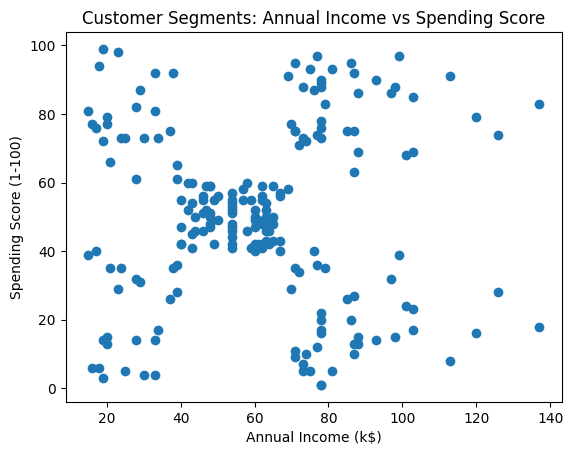

In [515]:
plt.scatter(X['AnnualIncome'], X['SpendingScore'])
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments: Annual Income vs Spending Score')
plt.show()

## 5. Determine Optimal Number of Clusters `(10 pts)`

- Run K-Means for K = 1 to 10.
- Store WCSS (within-cluster sum of squares).
- Plot the elbow curve.

For cluster = 1, SSE/WCSS is 269981.28000000014
For cluster = 2, SSE/WCSS is 181363.59595959607
For cluster = 3, SSE/WCSS is 106348.37306211119
For cluster = 4, SSE/WCSS is 73679.78903948837
For cluster = 5, SSE/WCSS is 44448.45544793369
For cluster = 6, SSE/WCSS is 37265.86520484345
For cluster = 7, SSE/WCSS is 30259.657207285458
For cluster = 8, SSE/WCSS is 25050.832307547524
For cluster = 9, SSE/WCSS is 21862.09267218289
For cluster = 10, SSE/WCSS is 19657.783608703947


Text(0, 0.5, 'WCSS')

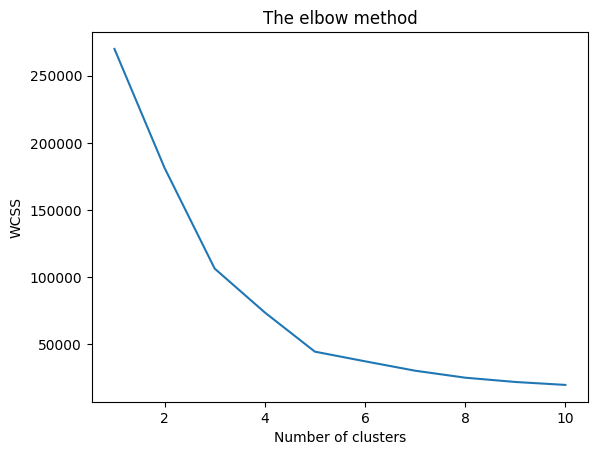

In [516]:
wcss=[]
sse = {}
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300,
                    n_init = 10, random_state = 0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    sse[i] = kmeans.inertia_
    print("For cluster = {}, SSE/WCSS is {}".format(i, sse[i]))

plt.plot(range(1, 11), wcss)
plt.title('The elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

## 6. Train K-Means with Optimal K `(10 pts)`


- Choose K based on the elbow method.
- Fit the K-Means model.
- Assign cluster labels to the dataset.
- Display first 10 labeled rows.

In [517]:
cluster_Kmeans = KMeans(n_clusters=6)
model_kmeans = cluster_Kmeans.fit(X)
pred_kmeans = model_kmeans.labels_
print(pred_kmeans)

unique, counts = np.unique(pred_kmeans, return_counts=True)
dict(zip(unique, counts))

[3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3
 4 3 4 3 4 3 1 3 4 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 0 2 0 1 0 2 0 2 0 1 0 2 0 2 0 2 0 2 0 1 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 5 2 5 2 5 2
 5 2 5 2 5 2 5 2 5 2 5 2 5 2 5]


{np.int32(0): np.int64(28),
 np.int32(1): np.int64(81),
 np.int32(2): np.int64(35),
 np.int32(3): np.int64(23),
 np.int32(4): np.int64(22),
 np.int32(5): np.int64(11)}

## 7. Visualize the Clusters `(10 pts)`

- Create a scatter plot showing the formed clusters.
- Color points by cluster.
- Plot cluster centroids as larger points.

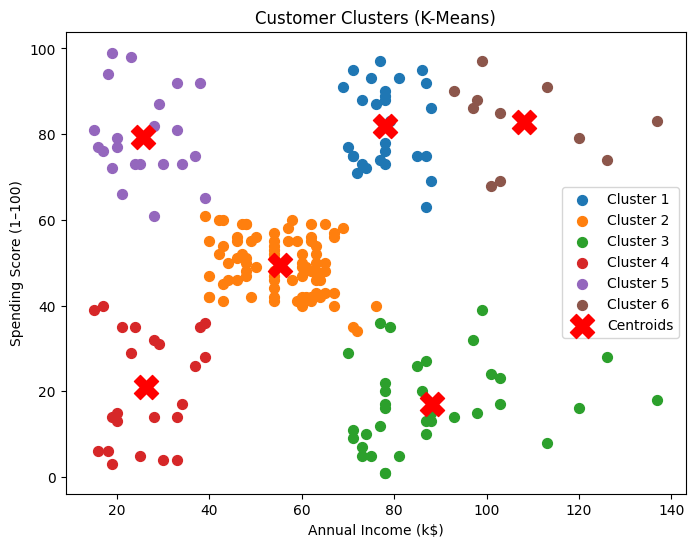

In [518]:
plt.figure(figsize=(8, 6))

# Plot each cluster separately so legend shows them individually
for i in range(model_kmeans.n_clusters):
    plt.scatter(
        X['AnnualIncome'][pred_kmeans == i],
        X['SpendingScore'][pred_kmeans == i],
        s=50,
        label=f"Cluster {i+1}"
    )

# Plot centroids
plt.scatter(
    model_kmeans.cluster_centers_[:, 0],
    model_kmeans.cluster_centers_[:, 1],
    s=300,
    c='red',
    marker='X',
    label='Centroids'
)

plt.title('Customer Clusters (K-Means)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1–100)')
plt.legend()
plt.show()


## 8. Cluster Interpretation



Answer the following (in text, not code): `(10 pts)`

- Which cluster represents high income, low spending users?
- Which cluster represents low income, high spending users?
- Which cluster might represent target customers for promotions?
- What business insights can you derive from the clusters?

# Answers


Which cluster represents high income, low spending users?
  
-Based on the scatter plot the cluster that represents the high income, low spending user is in the cluster 3 at the bottom right. Because they are plotted far to the right which means they are customers with high income but not spending too much.

Which cluster represents low income, high spending users?

-The low income, high spending users is in the cluster 5 because they are in the range of low income and plotted in the high spending score users.

Which cluster might represent target customers for promotions?

-For the target customers for the promotion cluster 1 or cluster 6 at the top right both group earned high income and high spend heavily. The cluster 6 or in the brown cluster are those we can call as Ultra-high income as version of the blue group. While the cluster 1 is we can these are VIPs.

What business insights can you derive from the clusters?

-The "Average" Customer (cluster 2): This is the biggest group. They earn an average amount and spend an average amount. They are the safe, steady income for the business.

-The "Impulse" Buyers/ Students (cluster 5): They don't have high salaries, but they love to shop. Sales, coupons, and discounts likely work best on them.

-The "Savers" (cluster 3): These people have plenty of money but aren't spending it at this mall. Business is missing out here maybe the products are not fancy enough for them, or the marketing isn't reaching them.

-The "True Fans" (cluster 1 & 6): These are the star customers. Since they have money and are willing to spend it, the business should focus on premium services or loyalty perks to make sure they don't switch to a competitor.

## 9. Add Age to the Clustering Model

Create a new 3D K-Means model using features: `(5 pts)`


- Age
- Annual Income
- Spending Score


In [519]:
X = df[['AnnualIncome', 'SpendingScore', 'Age']]

Visualize using a 3D scatter plot. `(5 pts)`

In [520]:
cluster_Kmeans = KMeans(n_clusters=6)
model_kmeans = cluster_Kmeans.fit(X)
pred_kmeans = model_kmeans.labels_

fig = px.scatter_3d(df, x='Age', y='AnnualIncome', z='SpendingScore', color=pred_kmeans)
fig.show()

## 10. 3D Cluster Interpretation



Answer the following (in text, not code): `(10 pts)`

- Are there meaningful and distinguishable clusters?
- What business insights can you derive from the clusters in 3D??

1.  **Are the 3D clusters meaningful and distinguishable?**
    
    Yes, the 3D clusters are meaningful and distinguishable. By incorporating 'Age' as an additional dimension, the clustering provides more granular and distinct customer segments compared to 2D models, allowing for a deeper understanding of customer behavior.

2.  **What business insights can you derive from the clusters in 3D?**
    The 3D clusters reveal six distinct customer segments, each with unique characteristics related to age, income, and spending habits. These insights enable targeted marketing strategies. For instance, Cluster 3 represents "Elite Shoppers" who are young to middle-aged with high income and high spending, requiring personalized luxury offers and top-tier loyalty programs. In contrast, Cluster 5, "Frugal Bargain Hunters," consists of middle-aged customers with low income and low spending, for whom promotions, sales, and value propositions would be most effective.
